In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
import seaborn as sns
from scipy import stats as scipystats
import statsmodels.api as sm

sys.path.insert(0, r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter")
from core import annotate_significance_vs_ref
import importlib
importlib.reload(sys.modules["core"])

<module 'core' from 'C:\\Users\\timon\\OneDrive\\Helmholtz\\Scripts\\Yagya_jupyter\\core.py'>

# ***import file saved at the end of script6 in dataprep*** 

In [10]:
######################################################import data############################################################################################

df = pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_code\complete_optimised4MLR_SCD_SCGE_merged_dataset.csv")
print(df[df['growthmedium'] == "SCGE"].date.unique())
df.drop(df[(df.Position == "Position_23") & (df.date == 21012021)].index, inplace=True)
df.drop(df[(df.Position == "Position_15") & (df.date == 20012021)].index, inplace=True)
#print(df[(df['date'] == 21012021) & (df['Position'] == "Position_23")])
#df['Birth_or_div_vol'] = df['Birth vol fl'].combine_first(df['Div vol fl'])

[23092021  3012023]


# ***assign complete_phase = False for some cells with faulty annotations (to exclude them from analysis)*** 

In [11]:
####################################################### assigning complete_phase = False to some faultily annotated cells ###########################################################
import warnings

with warnings.catch_warnings(record=True):
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCGE') & (df['date'] == 23092021) & (df['Position'] == 'Position_8') & (df['Cell_ID'] == 2)].index] = False
    #last cell cycle stage annotated wrong:
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 20012021) & (df['Position'] == 'Position_33') & (df['Cell_ID'] == 32)].index] = False
    #first generation number annotated wrong:
    df['generation_num'].loc[df[(df['growthmedium'] == 'SCGE') & (df['Position'] == 'Position_8') & (df['Cell_ID'] == 2) & (df['generation_num'] == 0)].index] = 2
    #relatives missing in last frame or missing from data altogether, therefore no system volume at last frame, therefore abs_growth_rate = Nan.
    # Labelling both G1 and S phases in these generations with missing relatives as incomplete phases because we have incomplete information
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCGE') & (df['Position'] == 'Position_27') & (df['Cell_ID'] == 48) & (df['generation_num'] == 1)].index] = False
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCGE') & (df['Position'] == 'Position_38') & (df['Cell_ID'] == 25) & (df['generation_num'] == 1)].index] = False
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 21012021) & (df['Position'] == 'Position_12') & (df['Cell_ID'] == 3) & (df['generation_num'] == 3)].index] = False
    # for this cell, the last frame of generation 1 G1 is labelled as generation 2 G1. correcting to generation_num = 1 would not be sufficient,
    # as all the other columns for this frame are calculated as per S phase. Therefore, labelling all phases in generation 1 for this cell incomplete
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 20012021) & (df['Position'] == 'Position_20') & (df['Cell_ID'] == 16)
                                & ((df['generation_num'] == 1)|(df['generation_num'] == 2))].index] = False
    # gen 4 skips G1 phase and goes directly from S to S. therefore no len_G1 value. removing gen4 completely
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 21012021) & (df['Position'] == 'Position_1') & (df['Cell_ID'] == 2)
                                & (df['generation_num'] == 4)].index] = False
    # gen 4 skips G1 phase and goes directly from S to S. therefore no len_G1 value. removing gen4 completely
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 20012021) & (df['Position'] == 'Position_11') & (df['Cell_ID'] == 3)
                                & (df['generation_num'] == 4)].index] = False
    #len_g1 value missing from gen 1 for some reason. remove gen 1 completely:
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 21012021) & (df['Position'] == 'Position_7') & (df['Cell_ID'] == 17)
                                & (df['generation_num'] == 1)].index] = False
    # gen 4 skips G1 phase and goes directly from S to S. therefore no len_G1 value. removing gen4 completely
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCGE') & (df['date'] == 23092021) & (df['Position'] == 'Position_24') & (df['Cell_ID'] == 1)
                                & (df['generation_num'] == 4)].index] = False
    # gen 3 skips G1 phase and goes directly from S to S. therefore no len_G1 value. removing gen3 completely
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 20012021) & (df['Position'] == 'Position_20') & (df['Cell_ID'] == 7)
                                & (df['generation_num'] == 3)].index] = False
    # gen 3 skips G1 phase and goes directly from S to S. therefore no len_G1 value. removing gen3 completely
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 21012021) & (df['Position'] == 'Position_28') & (df['Cell_ID'] == 7)
                                & (df['generation_num'] == 3)].index] = False
    # gen 5 skips G1 phase and goes directly from S to S. therefore no len_G1 value. removing gen5 completely
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 21012021) & (df['Position'] == 'Position_29') & (df['Cell_ID'] == 3)
                                & (df['generation_num'] == 5)].index] = False
    # gen 4 skips G1 phase and goes directly from S to S. therefore no len_G1 value. removing gen4 completely
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 21012021) & (df['Position'] == 'Position_15') & (df['Cell_ID'] == 3)
                                & (df['generation_num'] == 4)].index] = False
    # gen 5 skips G1 phase and goes directly from S to S. therefore no len_G1 value. removing gen5 completely
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 21012021) & (df['Position'] == 'Position_15') & (df['Cell_ID'] == 5)
                                & (df['generation_num'] == 5)].index] = False

# ***calculate cell volume CV for populations at every frame and at the last frame*** 
# ***create new df without buds [included with mothers] and with only the population from the last analysed frame of every position***  

In [12]:
df['sys_vol_at_frame_inc_G1_cells'] = df['sys_vol_atframe'].combine_first(df['cell_vol_fl'])
nobud_df= df[df["relationship"] != "bud"]
l = []
j = []
import warnings

with warnings.catch_warnings(record=True):
    for date in nobud_df['date'].unique():
        date_df  = nobud_df[nobud_df['date'] == date]
        for pos in date_df['Position'].unique():
            pos_df = date_df[date_df['Position'] == pos]
            pos_max_frame = (pos_df["frame_i"]).max()
            max_frame_df = pos_df[pos_df["frame_i"] == pos_max_frame]
            max_frame_df["mean_vol_last_frame"] = (max_frame_df["sys_vol_at_frame_inc_G1_cells"]).mean()
            max_frame_df["stdev_vol_last_frame"] = np.std(max_frame_df["sys_vol_at_frame_inc_G1_cells"])
            max_frame_df["CV_sys_vol_last_frame"] = (max_frame_df["stdev_vol_last_frame"])/(max_frame_df["mean_vol_last_frame"])
            l.append(max_frame_df)
            for frame in (pos_df["frame_i"]).unique():
                frame_df = pos_df[pos_df["frame_i"] == frame]
                frame_df["mean_vol_frame"] = (frame_df["sys_vol_at_frame_inc_G1_cells"]).mean()
                frame_df["stdev_vol_frame"] = np.std(frame_df["sys_vol_at_frame_inc_G1_cells"])
                frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
                j.append(frame_df)
all_last_frames_df = pd.concat(l).reset_index(drop = True)
new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

# ***Fig 1G dataprep: bootstrapping CV from last frames of positions: mixed positions strategy*** 

In [13]:
# STRATEGY:
# bootstrap position names within strains (10000 iterations)
# calculate last frame CVs with new position combination for every iteration
# plot og_lastframe_cellvol_CV as a barplot
# check for significance using CI of differences between bootstrapped CVs of strains as per:
# https://stats.stackexchange.com/questions/610134/t-test-on-bootstrapped-estimates#:~:text=The%20bootstrap%20is%20a%20valid,also%20available%20as%20an%20alternative.



In [14]:
from sklearn.utils import resample
import tqdm
import statsmodels.stats.api as sms

chosen_strains_df = all_last_frames_df[(all_last_frames_df["is_cell_dead"] == 0)]

seed = 42
n_iterations = 10000
og_cv_list = []
bootstrapped_cv_list = []

for medium in chosen_strains_df.growthmedium.unique():
    medium_df = chosen_strains_df[chosen_strains_df['growthmedium'] == medium]
    for strain in medium_df.Strain.unique():
        strain_df = medium_df[medium_df['Strain'] == strain]
        pos_list = np.array(strain_df.Position.unique())
        last_frame_cell_size_array = np.array(strain_df['sys_vol_at_frame_inc_G1_cells'])
        og_lastframe_cellvol_mean = last_frame_cell_size_array.mean()
        og_lastframe_cellvol_std = np.std(last_frame_cell_size_array)
        og_lastframe_cellvol_CV = og_lastframe_cellvol_std / og_lastframe_cellvol_mean

        for date in strain_df['date'].unique():
            date_df = strain_df[strain_df['date'] == date]
            rep_last_frame_cell_size_array = np.array(date_df['sys_vol_at_frame_inc_G1_cells'])
            rep_og_lastframe_cellvol_mean = rep_last_frame_cell_size_array.mean()
            rep_og_lastframe_cellvol_std = np.std(rep_last_frame_cell_size_array)
            rep_og_lastframe_cellvol_CV = rep_og_lastframe_cellvol_std / rep_og_lastframe_cellvol_mean
            og_info = {'date': date,
                       'medium': medium,
                       'strain': strain,
                       'og_lastframe_cellvol_CV': og_lastframe_cellvol_CV,
                       'rep_og_lastframe_cellvol_CV': rep_og_lastframe_cellvol_CV}
            og_cv_list.append(og_info)

        # Precompute per-position moments so each bootstrap iteration avoids expensive DataFrame concatenations.
        value_col = 'sys_vol_at_frame_inc_G1_cells'
        position_stats = (
            strain_df.groupby('Position')[value_col]
            .agg(
                n='size',
                total='sum',
                sumsq=lambda s: np.square(s.to_numpy()).sum()
            )
            .reindex(pos_list)
        )

        pos_names = position_stats.index.to_numpy()
        n_by_pos = position_stats['n'].to_numpy(dtype=float)
        total_by_pos = position_stats['total'].to_numpy(dtype=float)
        sumsq_by_pos = position_stats['sumsq'].to_numpy(dtype=float)

        n_pos = len(pos_names)
        rng = np.random.default_rng(seed)

        pbar = tqdm.tqdm(total=n_iterations, desc=f"Bootstrapping for {medium} {strain}")
        for i in range(n_iterations):
            sampled_idx = rng.integers(0, n_pos, size=n_pos)
            pos_list_resampled = pos_names[sampled_idx]

            # Count how often each original position was drawn in this bootstrap sample.
            draw_counts = np.bincount(sampled_idx, minlength=n_pos).astype(float)

            total_n = np.dot(draw_counts, n_by_pos)
            total_sum = np.dot(draw_counts, total_by_pos)
            bs_lastframe_cellvol_mean = total_sum / total_n

            total_sumsq = np.dot(draw_counts, sumsq_by_pos)
            variance = (total_sumsq / total_n) - (bs_lastframe_cellvol_mean ** 2)
            bs_lastframe_cellvol_std = np.sqrt(max(variance, 0.0))
            bs_lastframe_cellvol_CV = bs_lastframe_cellvol_std / bs_lastframe_cellvol_mean

            info = {
                'medium': medium,
                'strain': strain,
                'bs_lastframe_cellvol_CV': bs_lastframe_cellvol_CV,
                'iteration': i,
                'pos_list': pos_list_resampled
            }
            bootstrapped_cv_list.append(info)
            pbar.update(1)
        pbar.close()

bootstrapped_cv_df = pd.DataFrame.from_dict(bootstrapped_cv_list)
og_cv_df = pd.DataFrame.from_dict(og_cv_list)
display(bootstrapped_cv_df.head(10))

Bootstrapping for SCGE WHI5_CCR4_DD: 100%|██████████| 10000/10000 [00:00<00:00, 59569.38it/s]


,medium,strain,bs_lastframe_cellvol_CV,iteration,pos_list
0,SCD,MMY,0.333844,0,"[Position_1, Position_5, Position_4, Position_..."
1,SCD,MMY,0.330498,1,"[Position_1, Position_5, Position_2, Position_..."
2,SCD,MMY,0.370287,2,"[Position_5, Position_5, Position_5, Position_..."
3,SCD,MMY,0.315773,3,"[Position_6, Position_3, Position_4, Position_..."
4,SCD,MMY,0.345802,4,"[Position_5, Position_4, Position_3, Position_..."
5,SCD,MMY,0.314136,5,"[Position_3, Position_2, Position_1, Position_..."
6,SCD,MMY,0.348326,6,"[Position_6, Position_5, Position_2, Position_..."
7,SCD,MMY,0.338353,7,"[Position_5, Position_3, Position_1, Position_..."
8,SCD,MMY,0.359643,8,"[Position_5, Position_5, Position_5, Position_..."
9,SCD,MMY,0.342527,9,"[Position_3, Position_1, Position_4, Position_..."


# ***Fig 1G statistics SCD: calculate CIs of difference of bs_lastframe_cellvol_CV dist between strains*** 

In [15]:
# calculate CIs of difference of bs_lastframe_cellvol_CV dist between strains 
# as per https://stats.stackexchange.com/questions/610134/t-test-on-bootstrapped-estimates#:~:text=The%20bootstrap%20is%20a%20valid,also%20available%20as%20an%20alternative.

print("SCD CV stats:")
WT_df = bootstrapped_cv_df[(bootstrapped_cv_df["strain"] == "MMY") & (bootstrapped_cv_df["medium"] == "SCD")]
whi5del_df =  bootstrapped_cv_df[(bootstrapped_cv_df["strain"] == "WHI5DEL") & (bootstrapped_cv_df["medium"] == "SCD")]
bck2del_df = bootstrapped_cv_df[(bootstrapped_cv_df["strain"] == "BCK2DEL") & (bootstrapped_cv_df["medium"] == "SCD")]
whi5bck2dd_df =  bootstrapped_cv_df[(bootstrapped_cv_df["strain"] == "WHI5_BCK2_DD") & (bootstrapped_cv_df["medium"] == "SCD")]
ccr4del_df = bootstrapped_cv_df[(bootstrapped_cv_df["strain"] == "CCR4DEL") & (bootstrapped_cv_df["medium"] == "SCD")]
whi5ccr4dd_df =  bootstrapped_cv_df[(bootstrapped_cv_df["strain"] == "WHI5_CCR4_DD") & (bootstrapped_cv_df["medium"] == "SCD")]

#WT VS WHI5
WT_minus_whi5del = WT_df['bs_lastframe_cellvol_CV'].values - whi5del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_whi5del, q= [0.05, 0.95])
display("WT VS WHI5 95", ci_l_limit, ci_u_limit)

#WT VS BCK2
WT_minus_bck2del = WT_df['bs_lastframe_cellvol_CV'].values - bck2del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_bck2del, q= [0.05, 0.95])
display("WT VS BCK2 95", ci_l_limit, ci_u_limit)

#WT VS DD
WT_minus_dd = WT_df['bs_lastframe_cellvol_CV'].values - whi5bck2dd_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_dd, q= [0.05, 0.95])
display("WT VS DD 95", ci_l_limit, ci_u_limit)

#WT VS CCR4
WT_minus_ccr4del = WT_df['bs_lastframe_cellvol_CV'].values - ccr4del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_ccr4del, q= [0.05, 0.95])
display("WT VS CCR4 95", ci_l_limit, ci_u_limit)

#WT VS whi5ccr4dd
WT_minus_whi5ccr4dd = WT_df['bs_lastframe_cellvol_CV'].values - whi5ccr4dd_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_whi5ccr4dd, q= [0.05, 0.95])
display("WT VS whi5ccr4dd 95", ci_l_limit, ci_u_limit)

#DD VS BCK2
DD_minus_bck2del = whi5bck2dd_df['bs_lastframe_cellvol_CV'].values - bck2del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(DD_minus_bck2del, q= [0.05, 0.95])
display("DD VS BCK2 95", ci_l_limit, ci_u_limit)

#DD VS WHI5
DD_minus_whi5del = whi5bck2dd_df['bs_lastframe_cellvol_CV'].values - whi5del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(DD_minus_whi5del, q= [0.05, 0.95])
display("DD VS WHI5 95", ci_l_limit, ci_u_limit)

display("######################################################")
######################################################

#WT VS WHI5
WT_minus_whi5del = WT_df['bs_lastframe_cellvol_CV'].values - whi5del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_whi5del, q= [0.01, 0.99])
display("WT VS WHI5 99", ci_l_limit, ci_u_limit)

#WT VS BCK2
WT_minus_bck2del = WT_df['bs_lastframe_cellvol_CV'].values - bck2del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_bck2del, q= [0.01, 0.99])
display("WT VS BCK2 99", ci_l_limit, ci_u_limit)

#WT VS DD
WT_minus_dd = WT_df['bs_lastframe_cellvol_CV'].values - whi5bck2dd_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_dd, q= [0.01, 0.99])
display("WT VS DD 99", ci_l_limit, ci_u_limit)
                                    
#WT VS CCR4
WT_minus_ccr4del = WT_df['bs_lastframe_cellvol_CV'].values - ccr4del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_ccr4del, q= [0.01, 0.99])
display("WT VS CCR4 99", ci_l_limit, ci_u_limit)

#WT VS whi5ccr4dd
WT_minus_whi5ccr4dd = WT_df['bs_lastframe_cellvol_CV'].values - whi5ccr4dd_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_whi5ccr4dd, q= [0.01, 0.99])
display("WT VS whi5ccr4dd 99", ci_l_limit, ci_u_limit)

#DD VS BCK2
DD_minus_bck2del = whi5bck2dd_df['bs_lastframe_cellvol_CV'].values - bck2del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(DD_minus_bck2del, q= [0.01, 0.99])
display("DD VS BCK2 99", ci_l_limit, ci_u_limit)

#DD VS WHI5
DD_minus_whi5del = whi5bck2dd_df['bs_lastframe_cellvol_CV'].values - whi5del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(DD_minus_whi5del, q= [0.01, 0.99])
display("DD VS WHI5 99", ci_l_limit, ci_u_limit)


display("######################################################")
######################################################

#WT VS WHI5
WT_minus_whi5del = WT_df['bs_lastframe_cellvol_CV'].values - whi5del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_whi5del, q= [0.001, 0.999])
display("WT VS WHI5 99.9", ci_l_limit, ci_u_limit)

#WT VS BCK2
WT_minus_bck2del = WT_df['bs_lastframe_cellvol_CV'].values - bck2del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_bck2del, q= [0.001, 0.999])
display("WT VS BCK2 99.9", ci_l_limit, ci_u_limit)

#WT VS DD
WT_minus_dd = WT_df['bs_lastframe_cellvol_CV'].values - whi5bck2dd_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_dd, q= [0.001, 0.999])
display("WT VS DD 99.9", ci_l_limit, ci_u_limit)

#WT VS CCR4
WT_minus_ccr4del = WT_df['bs_lastframe_cellvol_CV'].values - ccr4del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_ccr4del, q= [0.001, 0.999])
display("WT VS CCR4 99.9", ci_l_limit, ci_u_limit)

#WT VS whi5ccr4dd
WT_minus_whi5ccr4dd = WT_df['bs_lastframe_cellvol_CV'].values - whi5ccr4dd_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_whi5ccr4dd, q= [0.001, 0.999])
display("WT VS whi5ccr4dd 99.9", ci_l_limit, ci_u_limit)
#DD VS BCK2
DD_minus_bck2del = whi5bck2dd_df['bs_lastframe_cellvol_CV'].values - bck2del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(DD_minus_bck2del, q= [0.001, 0.999])
display("DD VS BCK2 99.9", ci_l_limit, ci_u_limit)

#DD VS WHI5
DD_minus_whi5del = whi5bck2dd_df['bs_lastframe_cellvol_CV'].values - whi5del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(DD_minus_whi5del, q= [0.001, 0.999])
display("DD VS WHI5 99.9", ci_l_limit, ci_u_limit)

display("######################################################")



SCD CV stats:


'WT VS WHI5 95'

np.float64(-0.1330529908276086)

np.float64(-0.042777797994149325)

'WT VS BCK2 95'

...

np.float64(0.015866298678823696)

'DD VS WHI5 99.9'

np.float64(-0.14924330075651188)

np.float64(0.004489873843450631)

'######################################################'

# ***Fig 1G statistics SCGE: calculate CIs of difference of bs_lastframe_cellvol_CV dist between strains*** 

In [16]:
# calculate CIs of difference of bs_lastframe_cellvol_CV dist between strains 
# as per https://stats.stackexchange.com/questions/610134/t-test-on-bootstrapped-estimates#:~:text=The%20bootstrap%20is%20a%20valid,also%20available%20as%20an%20alternative.

print("SCGE CV stats:")
WT_df = bootstrapped_cv_df[(bootstrapped_cv_df["strain"] == "MMY") & (bootstrapped_cv_df["medium"] == "SCGE")]
whi5del_df =  bootstrapped_cv_df[(bootstrapped_cv_df["strain"] == "WHI5DEL") & (bootstrapped_cv_df["medium"] == "SCGE")]
bck2del_df = bootstrapped_cv_df[(bootstrapped_cv_df["strain"] == "BCK2DEL") & (bootstrapped_cv_df["medium"] == "SCGE")]
whi5bck2dd_df =  bootstrapped_cv_df[(bootstrapped_cv_df["strain"] == "WHI5_BCK2_DD") & (bootstrapped_cv_df["medium"] == "SCGE")]
ccr4del_df = bootstrapped_cv_df[(bootstrapped_cv_df["strain"] == "CCR4DEL") & (bootstrapped_cv_df["medium"] == "SCGE")]
whi5ccr4dd_df =  bootstrapped_cv_df[(bootstrapped_cv_df["strain"] == "WHI5_CCR4_DD") & (bootstrapped_cv_df["medium"] == "SCGE")]

#WT VS WHI5
WT_minus_whi5del = WT_df['bs_lastframe_cellvol_CV'].values - whi5del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_whi5del, q= [0.05, 0.95])
display("WT VS WHI5 95", ci_l_limit, ci_u_limit)

#WT VS BCK2
WT_minus_bck2del = WT_df['bs_lastframe_cellvol_CV'].values - bck2del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_bck2del, q= [0.05, 0.95])
display("WT VS BCK2 95", ci_l_limit, ci_u_limit)

#WT VS DD
WT_minus_dd = WT_df['bs_lastframe_cellvol_CV'].values - whi5bck2dd_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_dd, q= [0.05, 0.95])
display("WT VS DD 95", ci_l_limit, ci_u_limit)

#WT VS CCR4
WT_minus_ccr4del = WT_df['bs_lastframe_cellvol_CV'].values - ccr4del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_ccr4del, q= [0.05, 0.95])
display("WT VS CCR4 95", ci_l_limit, ci_u_limit)

#WT VS whi5ccr4dd
WT_minus_whi5ccr4dd = WT_df['bs_lastframe_cellvol_CV'].values - whi5ccr4dd_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_whi5ccr4dd, q= [0.05, 0.95])
display("WT VS whi5ccr4dd 95", ci_l_limit, ci_u_limit)

#DD VS BCK2
DD_minus_bck2del = whi5bck2dd_df['bs_lastframe_cellvol_CV'].values - bck2del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(DD_minus_bck2del, q= [0.05, 0.95])
display("DD VS BCK2 95", ci_l_limit, ci_u_limit)

#DD VS WHI5
DD_minus_whi5del = whi5bck2dd_df['bs_lastframe_cellvol_CV'].values - whi5del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(DD_minus_whi5del, q= [0.05, 0.95])
display("DD VS WHI5 95", ci_l_limit, ci_u_limit)

display("######################################################")
######################################################

#WT VS WHI5
WT_minus_whi5del = WT_df['bs_lastframe_cellvol_CV'].values - whi5del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_whi5del, q= [0.01, 0.99])
display("WT VS WHI5 99", ci_l_limit, ci_u_limit)

#WT VS BCK2
WT_minus_bck2del = WT_df['bs_lastframe_cellvol_CV'].values - bck2del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_bck2del, q= [0.01, 0.99])
display("WT VS BCK2 99", ci_l_limit, ci_u_limit)

#WT VS DD
WT_minus_dd = WT_df['bs_lastframe_cellvol_CV'].values - whi5bck2dd_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_dd, q= [0.01, 0.99])
display("WT VS DD 99", ci_l_limit, ci_u_limit)
                                    
#WT VS CCR4
WT_minus_ccr4del = WT_df['bs_lastframe_cellvol_CV'].values - ccr4del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_ccr4del, q= [0.01, 0.99])
display("WT VS CCR4 99", ci_l_limit, ci_u_limit)

#WT VS whi5ccr4dd
WT_minus_whi5ccr4dd = WT_df['bs_lastframe_cellvol_CV'].values - whi5ccr4dd_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_whi5ccr4dd, q= [0.01, 0.99])
display("WT VS whi5ccr4dd 99", ci_l_limit, ci_u_limit)

#DD VS BCK2
DD_minus_bck2del = whi5bck2dd_df['bs_lastframe_cellvol_CV'].values - bck2del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(DD_minus_bck2del, q= [0.01, 0.99])
display("DD VS BCK2 99", ci_l_limit, ci_u_limit)

#DD VS WHI5
DD_minus_whi5del = whi5bck2dd_df['bs_lastframe_cellvol_CV'].values - whi5del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(DD_minus_whi5del, q= [0.01, 0.99])
display("DD VS WHI5 99", ci_l_limit, ci_u_limit)


display("######################################################")
######################################################

#WT VS WHI5
WT_minus_whi5del = WT_df['bs_lastframe_cellvol_CV'].values - whi5del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_whi5del, q= [0.001, 0.999])
display("WT VS WHI5 99.9", ci_l_limit, ci_u_limit)

#WT VS BCK2
WT_minus_bck2del = WT_df['bs_lastframe_cellvol_CV'].values - bck2del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_bck2del, q= [0.001, 0.999])
display("WT VS BCK2 99.9", ci_l_limit, ci_u_limit)

#WT VS DD
WT_minus_dd = WT_df['bs_lastframe_cellvol_CV'].values - whi5bck2dd_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_dd, q= [0.001, 0.999])
display("WT VS DD 99.9", ci_l_limit, ci_u_limit)

#WT VS CCR4
WT_minus_ccr4del = WT_df['bs_lastframe_cellvol_CV'].values - ccr4del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_ccr4del, q= [0.001, 0.999])
display("WT VS CCR4 99", ci_l_limit, ci_u_limit)

#WT VS whi5ccr4dd
WT_minus_whi5ccr4dd = WT_df['bs_lastframe_cellvol_CV'].values - whi5ccr4dd_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(WT_minus_whi5ccr4dd, q= [0.001, 0.999])
display("WT VS whi5ccr4dd 99", ci_l_limit, ci_u_limit)
#DD VS BCK2
DD_minus_bck2del = whi5bck2dd_df['bs_lastframe_cellvol_CV'].values - bck2del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(DD_minus_bck2del, q= [0.001, 0.999])
display("DD VS BCK2 99.9", ci_l_limit, ci_u_limit)

#DD VS WHI5
DD_minus_whi5del = whi5bck2dd_df['bs_lastframe_cellvol_CV'].values - whi5del_df['bs_lastframe_cellvol_CV'].values
ci_l_limit, ci_u_limit = np.quantile(DD_minus_whi5del, q= [0.001, 0.999])
display("DD VS WHI5 99.9", ci_l_limit, ci_u_limit)

display("######################################################")



SCGE CV stats:


'WT VS WHI5 95'

np.float64(-0.1002029871849438)

np.float64(0.005945509556344598)

'WT VS BCK2 95'

...

np.float64(0.14684093212630023)

'DD VS WHI5 99.9'

np.float64(-0.05047552008179299)

np.float64(0.18302492713398338)

'######################################################'

# ***Fig 1G plot - colors changed later in inkscape*** 

C:\Users\timon\AppData\Local\Temp\ipykernel_22196\2210648148.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SCD_data['strain_to_int'] = SCD_data['strain']
C:\Users\timon\AppData\Local\Temp\ipykernel_22196\2210648148.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  SCD_data['strain_to_int'] = SCD_data['strain_to_int'].replace({'MMY':0, 'WHI5DEL':1, 'BCK2DEL':2, 'WHI5_BCK2_DD':3, 'CCR4DEL':4, 'WHI5_CCR4_DD':5})
C:\Users\timon\AppData\Local\Temp\ipykernel_22196\2210648148.py:14: SettingWithCopyWarning: 
A value 

95%: [-0.140, -0.032], 99%: [-0.151, -0.013], 99.9%: [-0.161, 0.007]
Pred. p-value: 0.0015, stars: **
95%: [-0.136, 0.005], 99%: [-0.156, 0.017], 99.9%: [-0.181, 0.029]
Pred. p-value: 0.055, stars: ns
95%: [-0.040, 0.030], 99%: [-0.046, 0.045], 99.9%: [-0.052, 0.058]
Pred. p-value: 0.055, stars: ns
95%: [-0.529, -0.141], 99%: [-0.591, -0.106], 99.9%: [-0.664, -0.062]
Pred. p-value: 0.0005, stars: ***
95%: [-0.449, -0.207], 99%: [-0.484, -0.158], 99.9%: [-0.520, -0.118]
Pred. p-value: 0.0005, stars: ***
95%: [-0.030, 0.040], 99%: [-0.045, 0.046], 99.9%: [-0.058, 0.052]
Pred. p-value: 0.055, stars: ns
95%: [-0.127, -0.031], 99%: [-0.139, -0.010], 99.9%: [-0.151, 0.009]
Pred. p-value: 0.0015, stars: **
95%: [-0.125, 0.002], 99%: [-0.144, 0.010], 99.9%: [-0.165, 0.016]
Pred. p-value: 0.055, stars: ns
95%: [-0.505, -0.146], 99%: [-0.564, -0.115], 99.9%: [-0.636, -0.080]
Pred. p-value: 0.0005, stars: ***
95%: [-0.439, -0.201], 99%: [-0.473, -0.157], 99.9%: [-0.522, -0.104]
Pred. p-value: 0.0

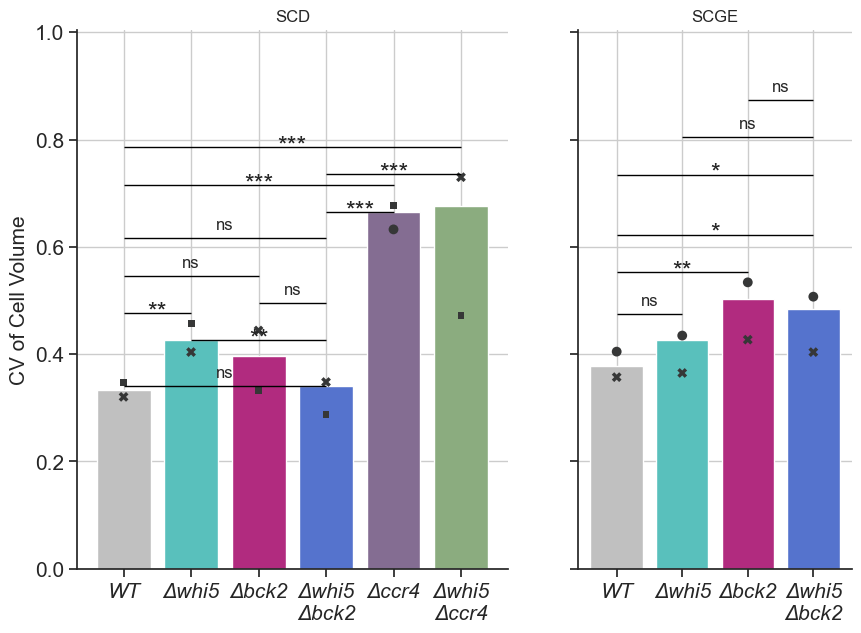

In [17]:
import importlib
import core
importlib.reload(core)
from core import annotate_significance_vs_ref

sns.set_context("notebook", rc={"lines.linewidth": 1.5})
sns.set_style("ticks")
palette ={"MMY": "silver", "WHI5DEL": "mediumturquoise", "BCK2DEL": "mediumvioletred", "WHI5_BCK2_DD": "royalblue",
          "CCR4DEL": "#856798", "WHI5_CCR4_DD": "#88b378"
            }

SCD_data = og_cv_df[og_cv_df["medium"] == "SCD"]
SCD_data['strain_to_int'] = SCD_data['strain']
SCD_data['strain_to_int'] = SCD_data['strain_to_int'].replace({'MMY':0, 'WHI5DEL':1, 'BCK2DEL':2, 'WHI5_BCK2_DD':3, 'CCR4DEL':4, 'WHI5_CCR4_DD':5})
a, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 7), sharex = False, sharey = True, gridspec_kw={'width_ratios': [1.1, 0.7]})
#bar_labels=SCD_data['bar_labels'][[0,4,2,6]]
a = sns.barplot(data= SCD_data,
                x = "strain", 
                y = "og_lastframe_cellvol_CV", 
                ax = ax1,
                yerr=None,
                order = ["MMY", "WHI5DEL", "BCK2DEL", "WHI5_BCK2_DD", "CCR4DEL", "WHI5_CCR4_DD"],
                legend=False,
                palette = palette)
#ax1.bar_label(ax1.containers[0], labels = bar_labels, fontsize=12, padding = -85)
#display(ax1.containers[0])
a = sns.scatterplot(data= SCD_data,
                x = "strain_to_int", 
                y = "rep_og_lastframe_cellvol_CV", 
                ax = ax1,
                s = 50,
                edgecolor = '#363737',
                linewidth = 0,
                style = 'date',
                color = '#363737',
                #order = ["MMY", "WHI5DEL", "BCK2DEL", "WHI5_BCK2_DD", "CCR4DEL", "WHI5_CCR4_DD"],
                legend = False
                   )

ax1.grid()
xtix = ["WT", "Δwhi5", "Δbck2", "Δwhi5\nΔbck2", "Δccr4", "Δwhi5\nΔccr4"]
ax1.set_xlabel("", fontsize = 15)
ax1.set_ylabel("CV of Cell Volume", fontsize = 15)
ax1.set_xticklabels(xtix, fontsize = 15, style = 'italic')
ax1.set_title("SCD")
ax1.set_ylim(0.0,1.0)
sns.despine(ax=ax1)
sns.despine(ax=ax2)
plt.legend([],[], frameon=False)
scd_bs = bootstrapped_cv_df[bootstrapped_cv_df['medium'] == 'SCD']
scd_order = ["MMY", "WHI5DEL", "BCK2DEL", "WHI5_BCK2_DD", "CCR4DEL", "WHI5_CCR4_DD"]

# MMY vs all
annotate_significance_vs_ref(ax1, scd_bs,
                             x_col='strain', y_col='bs_lastframe_cellvol_CV',
                             x_order=scd_order, ref_group="MMY",
                             test="bs", show_n=False)
# DD vs WHI5DEL and BCK2DEL (skip MMY — already shown above)
annotate_significance_vs_ref(ax1, scd_bs,
                             x_col='strain', y_col='bs_lastframe_cellvol_CV',
                             x_order=scd_order, ref_group="WHI5_BCK2_DD",
                             test="bs", show_n=False, y_gap=0)

SCGE_data = og_cv_df[(og_cv_df["medium"] == "SCGE") & (og_cv_df["strain"] != "CCR4DEL") & (og_cv_df["strain"] != "WHI5_CCR4_DD")]
SCGE_data['strain_to_int'] = SCGE_data['strain']
SCGE_data['strain_to_int'] = SCGE_data['strain_to_int'].replace({'MMY':0, 'WHI5DEL':1, 'BCK2DEL':2, 'WHI5_BCK2_DD':3})
#bar_labels=SCGE_data['bar_labels'][[8,12,10,14]]
a = sns.barplot(data= SCGE_data,
                x = "strain", 
                y = "og_lastframe_cellvol_CV", 
                ax = ax2,
                yerr=None,
                order = ["MMY", "WHI5DEL", "BCK2DEL", "WHI5_BCK2_DD"], 
                palette = palette)
#ax2.bar_label(ax2.containers[0], labels = bar_labels, fontsize=12, padding = -85)
a = sns.scatterplot(data= SCGE_data,
                x = "strain_to_int", 
                y = "rep_og_lastframe_cellvol_CV", 
                ax = ax2,
                s = 50,
                edgecolor = '#363737',
                linewidth = 0,
                style = 'date',
                color = '#363737',
                   )
ax2.grid()

xtix = ["WT", "Δwhi5", "Δbck2", "Δwhi5\nΔbck2"]
ax2.set_xlabel("", fontsize = 15)
ax2.set_ylabel("CV of Cell Volume", fontsize = 15)
ax2.set_xticklabels(xtix, fontsize = 15, style = 'italic')
ax2.set_title("SCGE")
ax1.tick_params(axis='y', which='major', labelsize=15)
ax2.set_ylim(0.0,1.0)

scge_bs = bootstrapped_cv_df[(bootstrapped_cv_df['medium'] == 'SCGE') &
                              (bootstrapped_cv_df['strain'] != 'CCR4DEL') &
                              (bootstrapped_cv_df['strain'] != 'WHI5_CCR4_DD')]
scge_order = ["MMY", "WHI5DEL", "BCK2DEL", "WHI5_BCK2_DD"]

# MMY vs all
annotate_significance_vs_ref(ax2, scge_bs,
                             x_col='strain', y_col='bs_lastframe_cellvol_CV',
                             x_order=scge_order, ref_group="MMY",
                             test="bs", show_n=False)
# DD vs WHI5DEL and BCK2DEL 
annotate_significance_vs_ref(ax2, scge_bs,
                             x_col='strain', y_col='bs_lastframe_cellvol_CV',
                             x_order=scge_order, ref_group="WHI5_BCK2_DD",
                             test="bs", show_n=False,y_gap=0.25)
plt.legend([],[], frameon=False)
plt.savefig(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\new_plots\panel2_withedits.svg", bbox_inches='tight', dpi =150)
plt.show()


# ***Fig 1F plot - colors changed later in inkscape*** 

C:\Users\timon\AppData\Local\Temp\ipykernel_22196\65973126.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chosen_strains_df.drop((chosen_strains_df[((chosen_strains_df["Strain"] == "CCR4DEL")|
C:\Users\timon\AppData\Local\Temp\ipykernel_22196\65973126.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtix, fontsize=13, style='italic')
C:\Users\timon\AppData\Local\Temp\ipykernel_22196\65973126.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ytix, fontsize=13)
C:\Users\timon\AppData\Local\Temp\ipykernel_22196\65973126.py:67: UserWarning: set_ticklabels() should only be used with a fixed 

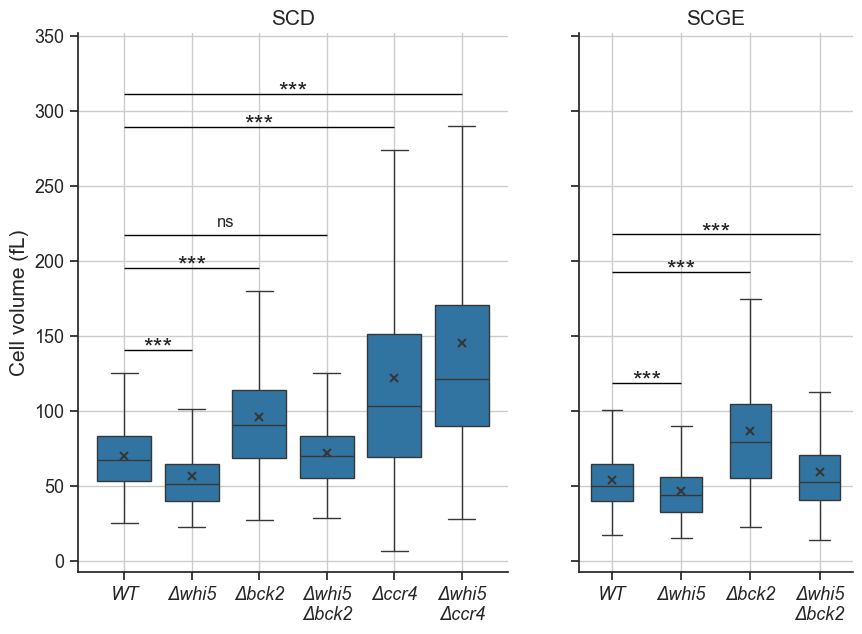


scd_df
Group: 'Strain'  |  Value: 'sys_vol_at_frame_inc_G1_cells'


,Strain,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,WT,382,69.7,67.0,1.13,8,Shapiro-Wilk,0.0,False
1,bck2Δ,376,95.7,90.7,1.63,8,Shapiro-Wilk,0.0,False
2,whi5Δ,370,56.3,51.1,2.05,21,Shapiro-Wilk,0.0,False
3,DD,463,72.1,69.8,0.98,13,Shapiro-Wilk,0.0,False
4,WHI5_CCR4_DD,280,145.0,120.9,3.37,15,Shapiro-Wilk,0.0,False
5,CCR4DEL,241,121.8,103.4,3.38,6,Shapiro-Wilk,0.0,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05)
0,WT vs bck2Δ,382,376,0.0000,0.0000,0.0000,True,True,True
1,WT vs whi5Δ,382,370,0.0000,0.0000,0.0000,True,True,True
2,WT vs DD,382,463,0.1416,0.1438,0.2496,False,False,False
3,WT vs WHI5_CCR4_DD,382,280,0.0000,0.0000,0.0000,True,True,True
4,WT vs CCR4DEL,382,241,0.0000,0.0000,0.0000,True,True,True
5,bck2Δ vs whi5Δ,376,370,0.0000,0.0000,0.0000,True,True,True
6,bck2Δ vs DD,376,463,0.0000,0.0000,0.0000,True,True,True
7,bck2Δ vs WHI5_CCR4_DD,376,280,0.0000,0.0000,0.0000,True,True,True
8,bck2Δ vs CCR4DEL,376,241,0.0000,0.0000,0.0002,True,True,True
9,whi5Δ vs DD,370,463,0.0000,0.0000,0.0000,True,True,True



scge_df
Group: 'Strain'  |  Value: 'sys_vol_at_frame_inc_G1_cells'


,Strain,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,WT,533,53.7,49.6,1.30,10,Shapiro-Wilk,0.0,False
1,bck2Δ,429,86.6,79.1,1.88,11,Shapiro-Wilk,0.0,False
2,whi5Δ,370,46.3,43.9,1.63,10,Shapiro-Wilk,0.0,False
3,DD,409,59.3,52.8,2.73,15,Shapiro-Wilk,0.0,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05)
0,WT vs bck2Δ,533,429,0.0000,0.0000,0.0000,True,True,True
1,WT vs whi5Δ,533,370,0.0000,0.0000,0.0000,True,True,True
2,WT vs DD,533,409,0.0009,0.0005,0.0153,True,True,True
3,bck2Δ vs whi5Δ,429,370,0.0000,0.0000,0.0000,True,True,True
4,bck2Δ vs DD,429,409,0.0000,0.0000,0.0000,True,True,True
5,whi5Δ vs DD,370,409,0.0000,0.0000,0.0000,True,True,True


In [26]:
sns.set_context("notebook", rc={"lines.linewidth": 1.5})
sns.set_style("ticks")

chosen_strains_df = all_last_frames_df[all_last_frames_df["is_cell_dead"] == 0]
chosen_strains_df.drop((chosen_strains_df[((chosen_strains_df["Strain"] == "CCR4DEL")|
                                          (chosen_strains_df["Strain"] == "WHI5_CCR4_DD")) & 
                                          (chosen_strains_df["growthmedium"] == "SCGE")
                                         ].index), inplace = True)
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}

x_order_scd  = ["MMY", "WHI5DEL", "BCK2DEL", "WHI5_BCK2_DD", "CCR4DEL", "WHI5_CCR4_DD"]
x_order_scge = ["MMY", "WHI5DEL", "BCK2DEL", "WHI5_BCK2_DD"]
y_col = "sys_vol_at_frame_inc_G1_cells"

d, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 7), sharey=True, gridspec_kw={'width_ratios': [1.1, 0.7]})

scd_df = chosen_strains_df[chosen_strains_df['growthmedium'] == "SCD"]
d = sns.boxplot(data=scd_df,
                x="Strain", y=y_col,
                showmeans=True,
                order=x_order_scd,
                showfliers=False,
                ax=ax1,
                meanprops={"marker":"x", "markerfacecolor":None, "markeredgecolor":"#363737",
                           "markersize":"6", "markeredgewidth": 1.5},
                **PROPS)

xtix = ["WT", "Δwhi5", "Δbck2", "Δwhi5\nΔbck2", "Δccr4", "Δwhi5\nΔccr4"]
sns.despine(ax=ax1)
ax1.grid()
ax1.set_xlabel("", fontsize=15)
ax1.set_title("SCD", fontsize=15)
ax1.set_ylabel("Cell volume (fL)", fontsize=15)
ax1.set_xticklabels(xtix, fontsize=13, style='italic')
ytix = ax1.get_yticklabels()
ax1.set_yticklabels(ytix, fontsize=13)

annotate_significance_vs_ref(ax1, scd_df, x_col="Strain", y_col=y_col,
                             x_order=x_order_scd, ref_group="MMY",
                             test="welch", show_n=False)

scge_df = chosen_strains_df[(chosen_strains_df['growthmedium'] == "SCGE") &
                             (chosen_strains_df['Strain'] != "CCR4DEL") &
                             (chosen_strains_df['Strain'] != "WHI5_CCR4_DD")]
d = sns.boxplot(data=scge_df,
                x="Strain", y=y_col,
                showmeans=True,
                order=x_order_scge,
                width=0.6,
                showfliers=False,
                ax=ax2,
                meanprops={"marker":"x", "markerfacecolor":None, "markeredgecolor":"#363737",
                           "markersize":"6", "markeredgewidth": 1.5},
                **PROPS)

ax2.grid()
sns.despine(ax=ax2)
ax2.set_xlabel("", fontsize=15)
ax2.set_ylabel("", fontsize=15)
ax2.set_title("SCGE", fontsize=15)
xtix2 = ["WT", "Δwhi5", "Δbck2", "Δwhi5\nΔbck2"]
ax2.set_xticklabels(xtix2, fontsize=13, style='italic')

annotate_significance_vs_ref(ax2, scge_df, x_col="Strain", y_col=y_col,
                             x_order=x_order_scge, ref_group="MMY",
                             test="welch", show_n=False)

#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig1\panel1.svg")
plt.show()

data_names = ["scd_df", "scge_df"]
for data, name in zip([scd_df, scge_df], data_names):
    core.run_stats(
        data,
        value_cols=[y_col],
        group_col="Strain",
        title=name,
    )


In [ ]:
normal_dummy_dist = np.random.normal(loc=0, scale=1, size=100)
df = pd.DataFrame({"normal_dummy_dist": normal_dummy_dist, "dummy_group": np.random.choice(["A", "B"], size=100)})

core.run_stats(
    df,
    value_cols=["normal_dummy_dist"],
    group_col=None,
    title="Normal Dummy Distribution",
)


KeyError: None